# 🚛 CCTV Truck Detection System
**YOLOv8 | Green Bounding Boxes | Unique IDs | Coordinates | Orientation | Parking Spaces**

---
### What this notebook does:
- Detects trucks in CCTV images using YOLOv8 (no training needed)
- Draws green bounding boxes with unique Truck IDs
- Shows coordinates (x, y, width, height) and orientation angle
- Counts total trucks detected
- Calculates available parking spaces
- Exports results to JSON


## Cell 1 — Install Dependencies

In [2]:
# Install YOLOv8 (ultralytics) and other required libraries
!pip install ultralytics opencv-python-headless matplotlib numpy -q

print('✅ All dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:00
✅ All dependencies installed!


## Cell 2 — Import Libraries

In [3]:
import cv2
import numpy as np
import json
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
from google.colab import files
from IPython.display import display, Image as IPImage
import ipywidgets as widgets

print('✅ Libraries imported successfully!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries imported successfully!


## Cell 3 — Load YOLOv8 Model
> This downloads the pretrained YOLOv8 model automatically. No dataset needed — it already knows how to detect trucks!

In [4]:
# Load YOLOv8 pretrained model
# 'yolov8n.pt' = nano (fastest), 'yolov8s.pt' = small, 'yolov8m.pt' = medium (most accurate)
model = YOLO('yolov8m.pt')  # Downloads automatically on first run

# COCO class IDs for vehicles
# class 7 = truck, class 2 = car, class 5 = bus
TRUCK_CLASS_IDS = [7]        # Only detect trucks
# TRUCK_CLASS_IDS = [2, 5, 7] # Uncomment to detect cars + buses + trucks

print('✅ YOLOv8 model loaded!')
print(f'   Model can detect {len(model.names)} object classes')
print(f'   Truck class ID: 7 → "{model.names[7]}"')

✅ YOLOv8 model loaded!
   Model can detect 80 object classes
   Truck class ID: 7 → "truck"


## Cell 4 — Configure Parking Space Settings
> Set the total number of parking slots in your parking area

In [27]:
# ============================================================
#  CONFIGURATION — Edit these values for your parking area
# ============================================================

TOTAL_PARKING_SPACES = 20    # Total number of parking slots in the lot
CONFIDENCE_THRESHOLD = 0.16   # Detection confidence (0.0 to 1.0)

# ============================================================
print(f'✅ Config set: {TOTAL_PARKING_SPACES} total parking spaces')
print(f'   Confidence threshold: {CONFIDENCE_THRESHOLD}')

✅ Config set: 20 total parking spaces
   Confidence threshold: 0.16


## Cell 5 — Core Detection Functions

In [28]:
def compute_orientation(x1, y1, x2, y2):
    """
    Compute orientation angle of the truck bounding box.
    Returns angle in degrees and a human-readable direction label.
    """
    width  = x2 - x1
    height = y2 - y1
    cx = x1 + width / 2
    cy = y1 + height / 2

    # Angle based on bounding box aspect ratio
    angle_rad = math.atan2(height, width)
    angle_deg = math.degrees(angle_rad)

    # Determine orientation label
    aspect = width / height if height > 0 else 1
    if aspect > 1.5:
        orientation = 'Horizontal'
    elif aspect < 0.67:
        orientation = 'Vertical'
    else:
        orientation = 'Diagonal'

    return round(angle_deg, 1), orientation, round(cx, 1), round(cy, 1)


def detect_trucks(image_path, total_spaces=TOTAL_PARKING_SPACES, conf=CONFIDENCE_THRESHOLD):
    """
    Main detection function.
    Returns annotated image, detection results dict, and output image path.
    """
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f'Could not load image: {image_path}')

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Run YOLOv8 inference
    results = model(img_rgb, conf=conf, verbose=False)[0]

    # Filter for trucks only
    truck_detections = []
    for i, box in enumerate(results.boxes):
        class_id = int(box.cls[0])
        if class_id not in TRUCK_CLASS_IDS:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        confidence       = round(float(box.conf[0]), 3)
        bw               = x2 - x1
        bh               = y2 - y1
        angle, orient, cx, cy = compute_orientation(x1, y1, x2, y2)

        truck_detections.append({
            'truck_id'   : f'TRUCK-{len(truck_detections)+1:02d}',
            'confidence' : confidence,
            'bbox'       : {'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                            'width': bw, 'height': bh},
            'center'     : {'cx': cx, 'cy': cy},
            'orientation': {'angle_deg': angle, 'direction': orient},
        })

    # ── Draw annotations on image ──────────────────────────────────────────
    annotated = img_rgb.copy()
    GREEN     = (0, 255, 0)
    WHITE     = (255, 255, 255)
    BLACK     = (0, 0, 0)
    YELLOW    = (255, 230, 0)
    font      = cv2.FONT_HERSHEY_SIMPLEX

    for det in truck_detections:
        b  = det['bbox']
        tid = det['truck_id']
        cx_ = int(det['center']['cx'])
        cy_ = int(det['center']['cy'])
        ang = det['orientation']['angle_deg']
        ori = det['orientation']['direction']
        conf_ = det['confidence']

        # Green bounding box (thick)
        cv2.rectangle(annotated, (b['x1'], b['y1']), (b['x2'], b['y2']), GREEN, 3)

        # Corner accents (small squares at corners)
        cs = 10  # corner size
        for cx_c, cy_c in [(b['x1'],b['y1']),(b['x2'],b['y1']),(b['x1'],b['y2']),(b['x2'],b['y2'])]:
            cv2.rectangle(annotated, (cx_c-cs//2, cy_c-cs//2), (cx_c+cs//2, cy_c+cs//2), GREEN, -1)

        # Center dot
        cv2.circle(annotated, (cx_, cy_), 5, YELLOW, -1)
        cv2.circle(annotated, (cx_, cy_), 7, GREEN, 2)

        # Orientation arrow (from center)
        arrow_len = min(b['width'], b['height']) // 3
        angle_rad = math.radians(ang)
        ex = int(cx_ + arrow_len * math.cos(angle_rad))
        ey = int(cy_ + arrow_len * math.sin(angle_rad))
        cv2.arrowedLine(annotated, (cx_, cy_), (ex, ey), YELLOW, 2, tipLength=0.3)

        # Label background (semi-transparent look with filled rect)
        label_lines = [
            f' {tid} ({conf_:.0%}) ',
            f' XY:({b["x1"]},{b["y1"]}) WH:({b["width"]},{b["height"]}) ',
            f' Angle:{ang}deg  {ori} ',
        ]
        label_y = b['y1'] - 6
        line_h  = 18
        max_w   = max(cv2.getTextSize(l, font, 0.45, 1)[0][0] for l in label_lines)

        # Background rectangle for labels
        rect_top = label_y - len(label_lines) * line_h - 4
        rect_top = max(0, rect_top)
        overlay  = annotated.copy()
        cv2.rectangle(overlay, (b['x1'], rect_top),
                      (b['x1'] + max_w + 6, label_y + 2), BLACK, -1)
        cv2.addWeighted(overlay, 0.65, annotated, 0.35, 0, annotated)

        # Draw label text lines
        for li, line in enumerate(label_lines):
            ty = label_y - (len(label_lines) - 1 - li) * line_h
            ty = max(ty, 14)
            # First line = truck ID in green, rest in white
            color = GREEN if li == 0 else WHITE
            cv2.putText(annotated, line, (b['x1'] + 3, ty),
                        font, 0.45, color, 1, cv2.LINE_AA)

    # ── Summary overlay (top-left panel) ──────────────────────────────────
    total_trucks    = len(truck_detections)
    available_spaces = max(0, total_spaces - total_trucks)
    occupied_spaces  = min(total_trucks, total_spaces)

    panel_lines = [
        f'  TRUCK DETECTION SYSTEM  ',
        f'  Total Trucks   : {total_trucks}',
        f'  Occupied Spaces: {occupied_spaces} / {total_spaces}',
        f'  Available Spaces: {available_spaces}',
        f'  Occupancy: {occupied_spaces/total_spaces*100:.0f}%',
    ]
    panel_h = len(panel_lines) * 22 + 12
    panel_w = 280

    overlay2 = annotated.copy()
    cv2.rectangle(overlay2, (8, 8), (8 + panel_w, 8 + panel_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay2, 0.70, annotated, 0.30, 0, annotated)
    cv2.rectangle(annotated, (8, 8), (8 + panel_w, 8 + panel_h), GREEN, 2)

    for li, line in enumerate(panel_lines):
        ty = 8 + 20 + li * 22
        color = GREEN if li == 0 else WHITE
        fw    = 1 if li > 0 else 1
        cv2.putText(annotated, line, (12, ty), font, 0.5, color, fw, cv2.LINE_AA)

    # Save output
    out_path = '/content/truck_detection_result.jpg'
    cv2.imwrite(out_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

    # Build results dict
    results_dict = {
        'summary': {
            'total_trucks_detected': total_trucks,
            'total_parking_spaces' : total_spaces,
            'occupied_spaces'      : occupied_spaces,
            'available_spaces'     : available_spaces,
            'occupancy_percent'    : round(occupied_spaces / total_spaces * 100, 1),
        },
        'trucks': truck_detections,
    }

    return annotated, results_dict, out_path


print('✅ Detection functions ready!')

✅ Detection functions ready!


## Cell 6 — Upload Your CCTV Image & Run Detection

In [31]:
# Upload your CCTV image
print('📂 Please upload your CCTV image...')
uploaded = files.upload()

if uploaded:
    image_filename = list(uploaded.keys())[0]
    image_path     = f'/content/{image_filename}'
    print(f'\n✅ Uploaded: {image_filename}')
    print('🔍 Running truck detection...')

    # Run detection
    annotated_img, results, output_path = detect_trucks(
        image_path,
        total_spaces=TOTAL_PARKING_SPACES,
        conf=CONFIDENCE_THRESHOLD
    )

    print('\n✅ Detection complete!')
else:
    print('❌ No image uploaded.')

📂 Please upload your CCTV image...


Saving trk 12.jpg to trk 12.jpg

✅ Uploaded: trk 12.jpg
🔍 Running truck detection...

✅ Detection complete!


## Cell 7 — Display Results

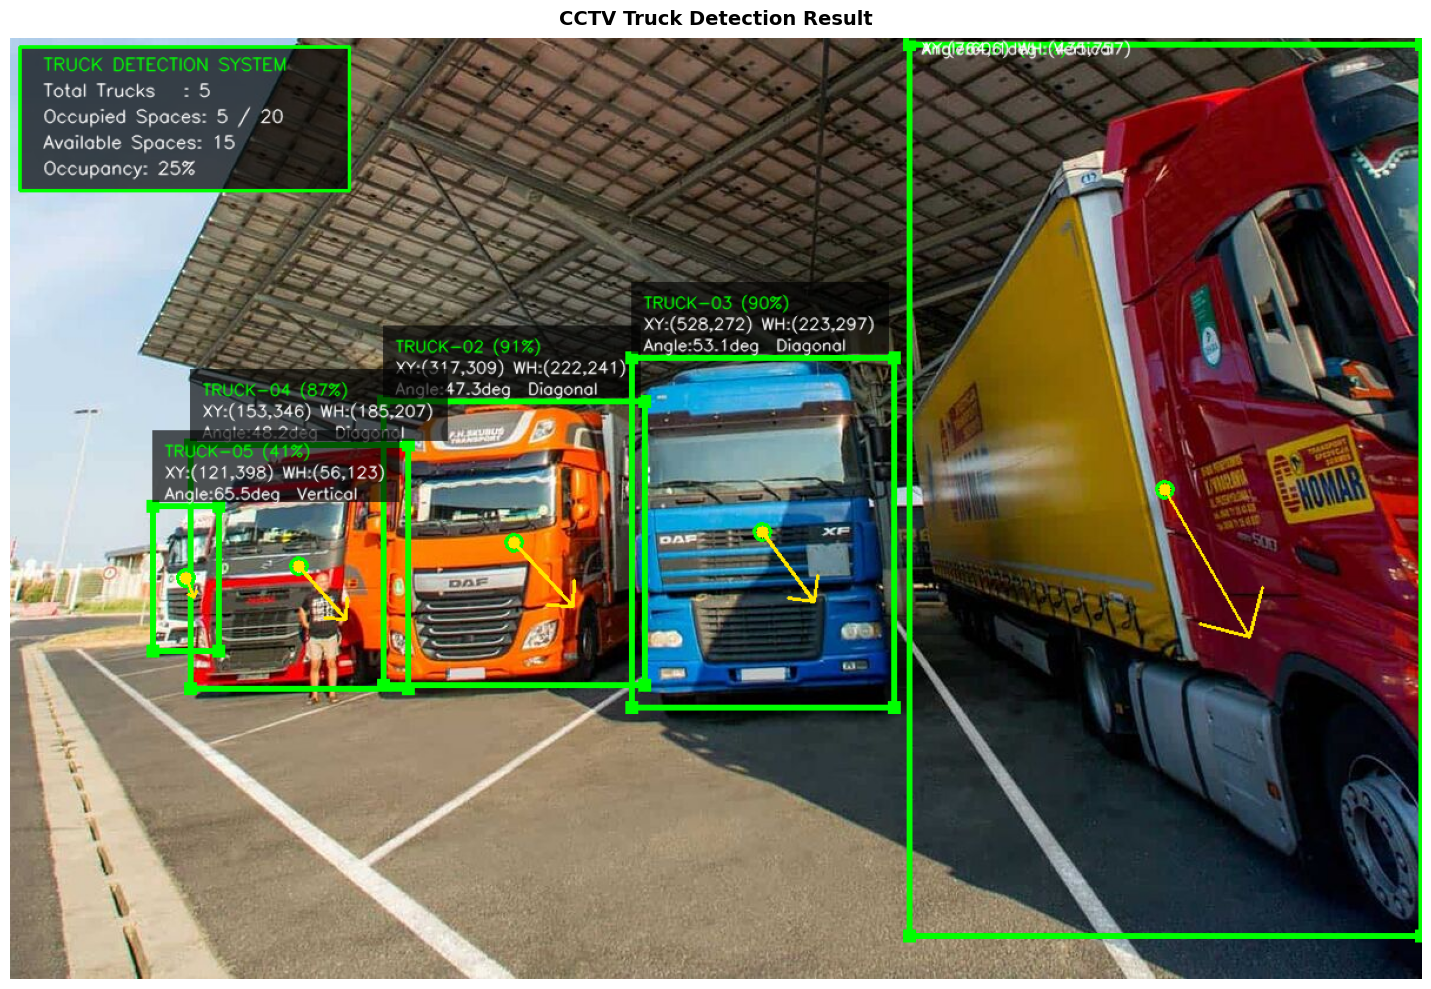


         PARKING LOT SUMMARY
  Total Trucks Detected  : 5
  Total Parking Spaces   : 20
  Occupied Spaces        : 5
  ✅ Available Spaces    : 15
  Occupancy              : 25.0%

  INDIVIDUAL TRUCK DETAILS
------------------------------------------------------------
  TRUCK-01  |  Confidence: 95.8%
    Bbox      : x1=764, y1=6, x2=1199, y2=763
    Size      : 435w x 757h px
    Center    : (981.5, 384.5)
    Angle     : 60.1°  |  Orientation: Vertical
------------------------------------------------------------
  TRUCK-02  |  Confidence: 91.0%
    Bbox      : x1=317, y1=309, x2=539, y2=550
    Size      : 222w x 241h px
    Center    : (428.0, 429.5)
    Angle     : 47.3°  |  Orientation: Diagonal
------------------------------------------------------------
  TRUCK-03  |  Confidence: 90.4%
    Bbox      : x1=528, y1=272, x2=751, y2=569
    Size      : 223w x 297h px
    Center    : (639.5, 420.5)
    Angle     : 53.1°  |  Orientation: Diagonal
----------------------------------------

In [32]:
# Display annotated image
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.imshow(annotated_img)
ax.axis('off')
ax.set_title('CCTV Truck Detection Result', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

# ── Print Summary Table ─────────────────────────────────────────────────────
s = results['summary']
print('\n' + '='*60)
print('         PARKING LOT SUMMARY')
print('='*60)
print(f'  Total Trucks Detected  : {s["total_trucks_detected"]}')
print(f'  Total Parking Spaces   : {s["total_parking_spaces"]}')
print(f'  Occupied Spaces        : {s["occupied_spaces"]}')
print(f'  ✅ Available Spaces    : {s["available_spaces"]}')
print(f'  Occupancy              : {s["occupancy_percent"]}%')
print('='*60)

# ── Print Per-Truck Details ──────────────────────────────────────────────────
if results['trucks']:
    print('\n  INDIVIDUAL TRUCK DETAILS')
    print('-'*60)
    for t in results['trucks']:
        b  = t['bbox']
        c  = t['center']
        o  = t['orientation']
        print(f"  {t['truck_id']}  |  Confidence: {t['confidence']:.1%}")
        print(f"    Bbox      : x1={b['x1']}, y1={b['y1']}, x2={b['x2']}, y2={b['y2']}")
        print(f"    Size      : {b['width']}w x {b['height']}h px")
        print(f"    Center    : ({c['cx']}, {c['cy']})")
        print(f"    Angle     : {o['angle_deg']}°  |  Orientation: {o['direction']}")
        print('-'*60)
else:
    print('\n  ⚠️  No trucks detected. Try lowering CONFIDENCE_THRESHOLD in Cell 4.')

## Cell 8 — Export Results to JSON & Download

In [ ]:
# Save results to JSON
json_path = '/content/truck_detection_results.json'
with open(json_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f'✅ Results saved to: {json_path}')
print('\n📥 Downloading files...')

# Download annotated image
files.download(output_path)

# Download JSON results
files.download(json_path)

print('✅ Download complete!')

## Cell 9 — (OPTIONAL) Run on Video File
> Upload an MP4 video and detect trucks frame by frame

In [ ]:
def process_video(video_path, total_spaces=TOTAL_PARKING_SPACES, conf=CONFIDENCE_THRESHOLD):
    """Process a video file and annotate each frame."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print('❌ Cannot open video file.')
        return

    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out_path = '/content/truck_detection_video.mp4'
    fourcc   = cv2.VideoWriter_fourcc(*'mp4v')
    writer   = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    print(f'🎥 Processing video: {total_frames} frames @ {fps:.1f} fps')

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Save temp frame
        temp_path = '/content/temp_frame.jpg'
        cv2.imwrite(temp_path, frame)

        # Detect
        annotated, res, _ = detect_trucks(temp_path, total_spaces, conf)
        annotated_bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
        writer.write(annotated_bgr)

        frame_idx += 1
        if frame_idx % 30 == 0:
            trucks = res['summary']['total_trucks_detected']
            avail  = res['summary']['available_spaces']
            print(f'  Frame {frame_idx}/{total_frames}  |  Trucks: {trucks}  |  Available: {avail}')

    cap.release()
    writer.release()
    print(f'\n✅ Video saved: {out_path}')
    files.download(out_path)


# Uncomment below to upload and process a video
# print('📂 Upload a video file (.mp4)...')
# uploaded_video = files.upload()
# if uploaded_video:
#     video_name = list(uploaded_video.keys())[0]
#     process_video(f'/content/{video_name}')

print('✅ Video processing function ready (uncomment to use)')

## Cell 10 — (OPTIONAL) Adjust Confidence & Re-run
> If trucks are not detected, lower the confidence. If too many false detections, raise it.

In [ ]:
# ── Quick re-run with different confidence ──────────────────────────────────
NEW_CONFIDENCE = 0.25   # Try 0.25 for harder-to-detect trucks

annotated_img, results, output_path = detect_trucks(
    image_path,
    total_spaces=TOTAL_PARKING_SPACES,
    conf=NEW_CONFIDENCE
)

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.imshow(annotated_img)
ax.axis('off')
ax.set_title(f'Re-run with confidence={NEW_CONFIDENCE}', fontsize=14, pad=10)
plt.tight_layout()
plt.show()

s = results['summary']
print(f'Trucks: {s["total_trucks_detected"]}  |  Available: {s["available_spaces"]} / {s["total_parking_spaces"]}')